In [ ]:
# 基础库
import os
import re
import time
import sys  # 保留 sys 库
import subprocess
import random
import copy
import pickle
import gc
import warnings
import math
import bisect

# 科学计算和数据处理库
import numpy as np
from numpy import array, sqrt, sin, cos, tan, histogram2d

# h5py 库用于处理 HDF5 数据
import h5py

# Matplotlib 用于可视化
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib import units
from matplotlib.gridspec import GridSpec

# Astropy 库和常量
import astropy
from astropy.io import ascii
import astropy.units as u
from astropy.cosmology import Planck18 as cosmo
from astropy.constants import G, c, m_e, m_p

# SciPy 库，用于数值计算和数学运算
from scipy.integrate import quad
from scipy.optimize import root_scalar
from scipy.spatial import cKDTree
from scipy.stats import lognorm

# 多进程和并行计算
import multiprocessing
from multiprocessing import Pool, cpu_count
from joblib import Parallel, delayed
from tqdm import tqdm

# 3D 绘图
from mpl_toolkits.mplot3d import Axes3D

# 设置宇宙学常量
H0 = cosmo.H0

# 设置默认值
default_level_input = "8"
default_AGN_name = "f"
default_X_num = 100
default_Y_num = 100
default_LC_bins = 400
default_threshold = 1e-4
default_vectors = "on"
# 过滤无关参数，保留不以 '--' 开头的参数
args = [arg for arg in sys.argv[1:] if not arg.startswith("--")]

# 定义函数来获取参数
def get_int_arg(args, index, default):
    try:
        return int(args[index])
    except (IndexError, ValueError):
        return default

def get_float_arg(args, index, default):
    try:
        return float(args[index])
    except (IndexError, ValueError):
        return default
def get_str_arg(args, index, default):
    try:
        return str(args[index])
    except (IndexError, ValueError):
        return default
# 提取参数
level_input = args[0] if len(args) > 0 else default_level_input
AGN_name = args[1] if len(args) > 1 else default_AGN_name
X_num = get_int_arg(args, 2, default_X_num)
Y_num = get_int_arg(args, 3, default_Y_num)
LC_bins = get_int_arg(args, 4, default_LC_bins)
threshold = get_float_arg(args, 5, default_threshold)
threshold_name = get_str_arg(args, 5, default_threshold)
vectors_switch = args[0] if len(args) > 0 else default_vectors
# 打印参数验证
print(f"Level Input: {level_input}")
print(f"AGN Name: {AGN_name}")
print(f"X Num: {X_num}")
print(f"Y Num: {Y_num}")
print(f"LC Bins: {LC_bins}")
print(f"Threshold: {threshold}")
Boxname = "100"
#AGN_info = "NoBH"
Bin_num = 2**int(level_input)
# 解析 level 参数
level = f"lv{level_input}"  # 转换为 "lv9"

# 根据 AGN_name 确定 AGN_info
AGN_info_dict = {
    "f": "Fiducial",
    "n": "NoBH"
    # 其他映射规则可以根据需要添加
}
AGN_info = AGN_info_dict.get(AGN_name, "Unknown")

font_label = {
    'family': 'serif',
    'size': 25
}

tick_size = 25

font_legend= {
    'family': 'serif',
    'size': 20
}
mp_value = m_p.to('g').value
# 宇宙学参数
Omega_0 = 0.3090  # 物质密度参数
Omega_Lambda = 0.6910  # 暗能量密度参数
H_0 = 67.66  # 哈勃常数，单位为 km/s/Mpc
c = 299792.458  # 光速，单位为 km/s

# 计算共动距离和尺度因子的函数
def comoving_distance(z, Omega_0 = 0.3090, Omega_Lambda = 0.6910, H_0 = 67.66):
    integrand = lambda zp: 1.0 / np.sqrt(Omega_0 * (1.0+zp)**3 + Omega_Lambda)
    integral, _ = quad(integrand, 0, z)
    return c/H_0 * integral

def scale_factor(z):
    return 1.0 / (1.0 + z)

# 已知共动距离，求红移和尺度因子的函数
def find_redshift_and_scale_factor(dC):
    # 定义被求解的方程
    equation = lambda z: comoving_distance(z) - dC

    # 使用root_scalar函数求解方程
    sol = root_scalar(equation, bracket=[0, 10])

    # 检查解是否收敛，如果不收敛则返回None
    if not sol.converged:
        return None, None

    # 返回红移和尺度因子
    z = sol.root
    a = scale_factor(z)
    return z, a
def compute_electron_density(gas_density, electron_abundance):
    return gas_density * 6.77e-31 * electron_abundance / mp_value

def find_nearest_grid_points(kdtree, lc_positions):
    # 使用 KDTree 查找最近的 grid cell
    _, indices = kdtree.query(lc_positions, k=1)  # 找到最近的一个网格单元
    return indices
def process_snapshot(file_path):
    with h5py.File(file_path, 'r') as file:
        # 读取 GridPos 和其他数据
        gridpos_data = file['/Cell/GridPos'][:]
        electron_abundance_data = file['/Cell/ElectronAbundance'][:]
        gas_density_data = file['/Cell/GasDensity'][:]
        Boxsize = file['Parameters'].attrs['BoxSize']
        # 读取缩放因子
        a = file['/Header'].attrs['Time']
        h = file['Parameters'].attrs['HubbleParam']
        a_scaling = file['/Cell/GasDensity'].attrs['a_scaling']
        h_scaling = file['/Cell/GasDensity'].attrs['h_scaling']
        # 计算电子数密度
        print("a:", a, a_scaling)
        print("h", h, h_scaling)
        electron_density_data = compute_electron_density(gas_density_data, electron_abundance_data)*h**h_scaling
        #electron_density = gas_density_data*6.77e-31 * electron_abundance_data / mp
        # 输出数据形状和前几行数据来验证
        #print("GridPos ple of ElectronAbundance data:", electron_abundance_data[:5])
        #print("Sadata shape:", gridpos_data.shape)
        #print("ElectronAbundance data shape:", electron_abundance_data.shape)
        #print("GasDensity data shape:", gas_density_data.shape)
        #print("Sample of GridPos data:", gridpos_data[:5])
        #print("Sammple of GasDensity data:", gas_density_data[:5])
        print("Boxsize:", Boxsize)
        sys.stdout.flush()
        # 创建 KD 树
        kdtree = cKDTree(gridpos_data)

        return kdtree, electron_density_data, Boxsize

def process_snapshot_connection(file_path_low, file_path_up):
    with h5py.File(file_path_low, 'r') as file:
        # 读取 GridPos 和其他数据
        gridpos_data_low = file['/Cell/GridPos'][:]
        electron_abundance_data_low = file['/Cell/ElectronAbundance'][:]
        gas_density_data_low = file['/Cell/GasDensity'][:]
        Boxsize_low = file['Parameters'].attrs['BoxSize']
        # 读取缩放因子
        a_low = file['/Header'].attrs['Time']
        h_low = file['Parameters'].attrs['HubbleParam']
        a_scaling = file['/Cell/GasDensity'].attrs['a_scaling']
        h_scaling = file['/Cell/GasDensity'].attrs['h_scaling']
        # 计算电子数密度
        print("a_low:", a_low, a_scaling)
        print("h_low", h_low, h_scaling)
        electron_density_data_low = compute_electron_density(gas_density_data_low, electron_abundance_data_low)*a_low**a_scaling*h_low**h_scaling
        #electron_density = gas_density_data*6.77e-31 * electron_abundance_data / mp
        # 输出数据形状和前几行数据来验证
        #print("GridPos ple of ElectronAbundance data:", electron_abundance_data[:5])
        #print("Sadata shape:", gridpos_data.shape)
        #print("ElectronAbundance data shape:", electron_abundance_data.shape)
        #print("GasDensity data shape:", gas_density_data.shape)
        #print("Sample of GridPos data:", gridpos_data[:5])
        #print("Sammple of GasDensity data:", gas_density_data[:5])
        print("Boxsize:", Boxsize_low)
        print(f"gridpos_data_low top10:{gridpos_data_low[:10]}")
        sys.stdout.flush()
        # 创建 KD 树
    with h5py.File(file_path_up, 'r') as file:
        # 读取 GridPos 和其他数据
        gridpos_data_up = file['/Cell/GridPos'][:]
        electron_abundance_data_up = file['/Cell/ElectronAbundance'][:]
        gas_density_data_up = file['/Cell/GasDensity'][:]
        Boxsize_up = file['Parameters'].attrs['BoxSize']
        # 读取缩放因子
        a_up = file['/Header'].attrs['Time']
        h_up = file['Parameters'].attrs['HubbleParam']
        a_scaling = file['/Cell/GasDensity'].attrs['a_scaling']
        h_scaling = file['/Cell/GasDensity'].attrs['h_scaling']
        # 计算电子数密度
        print("a_up:", a_up, a_scaling)
        print("h_up", h_up, h_scaling)
        electron_density_data_up = compute_electron_density(gas_density_data_up, electron_abundance_data_up)*a_up**a_scaling*h_up**h_scaling
        #electron_density = gas_density_data*6.77e-31 * electron_abundance_data / mp
        # 输出数据形状和前几行数据来验证
        #print("GridPos ple of ElectronAbundance data:", electron_abundance_data[:5])
        #print("Sadata shape:", gridpos_data.shape)
        #print("ElectronAbundance data shape:", electron_abundance_data.shape)
        #print("GasDensity data shape:", gas_density_data.shape)
        #print("Sample of GridPos data:", gridpos_data[:5])
        #print("Sammple of GasDensity data:", gas_density_data[:5])
        print("Boxsize_up:", Boxsize_up)
        print(f"gridpos_data_low top10:{gridpos_data_up[:10]}")
        sys.stdout.flush()

    #kdtree = cKDTree(gridpos_data)
    return kdtree, electron_density_data, Boxsize

def assign_density_to_lc_bins(LC_shifted, kdtree, electron_density_data):
    # 将 LC_shifted 变为二维数组，以便于 KDTree 查询
    LC_shifted_flat = LC_shifted.reshape(-1, 3)
    
    # 找到每个 bin 的最近网格点索引
    indices = find_nearest_grid_points(kdtree, LC_shifted_flat)
    
    # 根据索引赋值电子数密度
    electron_density_in_lc = electron_density_data[indices]
    
    # 将结果还原为 LC_shifted 的形状
    ne_LC_shifted = electron_density_in_lc.reshape(LC_shifted.shape[:2])
    return ne_LC_shifted 

# 并行化 assign_density_to_lc_bins 的计算
def parallel_assign_density_to_lc_bins(LC_shifted, kdtree, electron_density_data, n_jobs=-1):
    LC_shifted_flat = LC_shifted.reshape(-1, 3)
    indices = Parallel(n_jobs=n_jobs)(delayed(kdtree.query)(pos) for pos in LC_shifted_flat)
    indices = np.array([i[1] for i in indices])  # 获取索引
    electron_density_in_lc = electron_density_data[indices]
    return electron_density_in_lc.reshape(LC_shifted.shape[:2])
# 并行化 calculate_DM_IGM 的计算
def parallel_calculate_DM_IGM(ne_LC_shifted, z_list, dz, DM_IGM_LC_tot, h, h_scaling, n_jobs=-1, c_value = 299792.458):
    LC_num = ne_LC_shifted.shape[0]
    
    def calculate_row(i):
        DM_row = np.zeros(ne_LC_shifted.shape[1])
        for j in range(ne_LC_shifted.shape[1] - 1):
            if j == 0:
                DM_row[0] = c_value / H_0 * ne_LC_shifted[i][0] * (1 + z_list[0]) * dz[0] / np.sqrt(Omega_0 * (1 + z_list[0])**3 + Omega_Lambda) * 1e6
            else:
                DM_row[j] = DM_row[j - 1] + c_value / H_0 * ne_LC_shifted[i][j] * (1 + z_list[j]) * dz[j] / np.sqrt(Omega_0 * (1 + z_list[j])**3 + Omega_Lambda) * 1e6
        DM_row /= h  # 如果需要，转化为物理单位
        return DM_row
    
    DM_IGM_LC = Parallel(n_jobs=n_jobs)(delayed(calculate_row)(i) for i in range(LC_num))
    return np.array(DM_IGM_LC)

# 定义计算单条观测线的 DM 函数
def calculate_DM_IGM(ne_LC_shifted, z_list, dz, DM_IGM_LC_tot, h=0.6774, h_scaling=1, c_value=299792.458):
    LC_num, DM_IGM_num = ne_LC_shifted.shape
    DM_IGM_LC = np.zeros((LC_num, DM_IGM_num))
    
    # 检查长度一致性
    min_length = min(DM_IGM_num, len(z_list), len(dz))
    z_list = z_list[:min_length]
    dz = dz[:min_length]
    
    for i in range(LC_num):
        for j in range(min_length - 1):
            if len(DM_IGM_LC_tot) == 0:
                DM_IGM_LC[i][0] = (
                    c_value / H_0 * ne_LC_shifted[i][0] * (1 + z_list[0]) * dz[0] 
                    / np.sqrt(Omega_0 * (1 + z_list[0])**3 + Omega_Lambda) * 1e6
                )
            else:
                DM_IGM_LC[i][0] = (
                    DM_IGM_LC_tot[-1][i][-1] + c_value / H_0 * ne_LC_shifted[i][0] * (1 + z_list[0]) * dz[0] 
                    / np.sqrt(Omega_0 * (1 + z_list[0])**3 + Omega_Lambda) * 1e6
                )
            DM_IGM_LC[i][j+1] = (
                DM_IGM_LC[i][j] + c_value / H_0 * ne_LC_shifted[i][j+1] * (1 + z_list[j+1]) * dz[j+1] 
                / np.sqrt(Omega_0 * (1 + z_list[j+1])**3 + Omega_Lambda) * 1e6
            )
    return DM_IGM_LC

# 打开 HDF5 文件
file_path = f'/home/zhaozhang/local/Grid_data/L100N1024_{AGN_info}/'
storage_path = f"/home/zhaozhang/local/Grid_data/Grid_figure/L100N1024_{AGN_info}/"
if os.path.exists(storage_path) !=1:
    os.mkdir(storage_path)
file_N_min = 12
file_N_max = 20
gridfile = []
grid_data_name = [name for name in os.listdir(file_path) if re.match(f'fullbox_\\d+_{AGN_name}_lv{level_input}.hdf5', name)]
grid_numbers = [int(re.findall(r'\d+', name)[0]) for name in grid_data_name ]
grid_numbers.sort(reverse=True)
redshifts = []
prev_redshift = None 
for num in grid_numbers:
    if (num >= file_N_min) & (num<=file_N_max):
        grid_file = "fullbox_{:03d}_{}_lv{}.hdf5".format(num, AGN_name, level_input)
        grid_file_path = os.path.join(file_path, grid_file)
        with h5py.File(grid_file_path, 'r') as file:
            redshift = file["Header"].attrs["Redshift"]
            if prev_redshift is None or redshift - prev_redshift >= 0.1:
                gridfile.append(grid_file_path)
                redshifts.append(redshift)
                prev_redshift = redshift  # Update the previous redshift
for path, redshift in zip(gridfile, redshifts):
    print(redshift, path)
    sys.stdout.flush()
#z_max = np.max(redshifts)
z_max = 1.0
Snap_num = len(gridfile)
X_Bound_shift = 0
Y_Bound_shift = 0
Z_Bound_shift = 0
#X_num = 100
#Y_num = 100
LC_num = Y_num*X_num
n_bins = LC_bins
z_temp_tot = []
z_list_tot =  []
z_list_center =  []
a_list_tot = []
dz_tot = []
DM_IGM_num = n_bins
ne_LC_shifted_tot = []
ne_LC_Ion_shifted_tot = []
DM_IGM_LC_tot = []
Bin_centers_shifted_tot = []
Distacne = []
start_time = time.time() 
z_temp = 0 
LC_length_total = 0
index_z = 0
overlap_range = 5
mp = m_p.to(u.g).value
rank = 0
if vectors_switch == "on":
    vectors = [
        [1.2329498412532303, -1.6584734880051313, 1.0],
        [-1.1539290392325818, -1.0, -3.040251011741983],
        [1.744995976117328, 13.752138755257217, -1.0],
        [-1.0, 2.9812078515745277, -1.3489175116209866],
        [5.076528778669732, -1.0, -1.1361961103048872],
        [-6.813263281120863, 1.134827238165392, 1.0],
        [-1.0, -1.5290302860876819, -3.2819785904825287],
        [-40.0549738736401, 1.0, -1.3184549847052658],
        [1.0, -3.415390704583581, -2.0608445853097486],
        [1.0, 1.2628610975439722, 1.2395592438012262],
        [-1.0, -2.1188857980761937, 1.8534181650330381],
        [-25.22732855898138, -1.0, 2.2480963353240346],
        [-1.0, -1.0592479438301083, -3.5114161086979037],
        [-2.628661503957581, -5.443052749112832, -1.0],
        [-3.3680050405460173, 2.336377020616031, 1.0],
        [-4.350208614522061, -3.026052442657449, -1.0],
        [-1.644234746160297, 5.240466355192378, -1.0],
        [1.045461547790559, -3.678980348250516, -1.0],
        [1.692172470990982, -1.0, -11.013018646497054]
    ]
    vectors_index = 0
if vectors_switch == "off":
    vectors = []
for ii in range(Snap_num):
    with h5py.File(gridfile[ii], 'r') as file:
        a = file['/Header'].attrs['Time']
        h = file['Parameters'].attrs['HubbleParam']
        a_scaling = file['/Cell/GasDensity'].attrs['a_scaling']
        h_scaling = file['/Cell/GasDensity'].attrs['h_scaling']
        # 计算电子数密度
    kdtree, electron_density_data, Boxsize = process_snapshot(gridfile[ii])
    ne_LC_shifted = np.zeros([LC_num, n_bins])
    ne_LC_Ion_shifted = np.zeros([LC_num, n_bins])
    DM_IGM_LC = np.zeros([LC_num, DM_IGM_num]) 
    Lbox =  Boxsize/h
    L = Lbox
    print("Start the DM calculate part of {}".format(gridfile[ii]))
    z_low = redshifts[ii]
    #z_up = redshifts[ii+1]
    z_up = redshifts[ii + 1] if ii + 1 < Snap_num else z_max
    # 达到高红移处，对两个BOX进行重叠处理
    random_num_0_2 = 0
    m = 0
    n = 0
    o = 0
    while (z_temp  < z_up):
        if z_temp < z_max:
            # 当前 Box 内的 DM 计算
            print(f"Processing within Box: z_temp = {z_temp}, z_up = {z_up}")
            sys.stdout.flush()
            if rank == 0: 
                print(f"rank {rank}: z_temp<z_up")
                sys.stdout.flush()
                print(f"rank {rank}: z_temp = {z_temp}")
                sys.stdout.flush()
                print(f"rank {rank}: z_up = {z_up}")
                sys.stdout.flush()
            if rank == 0:     
                if vectors_switch == "off":
                    d_index = np.zeros(3)
                    d_index[0] = random.uniform(0, 1) if random.random() < 0.5 else random.uniform(-1, 0)
                    d_index[1] = random.uniform(0, 1) if random.random() < 0.5 else random.uniform(-1, 0)
                    d_index[2] = random.uniform(0, 1) if random.random() < 0.5 else random.uniform(-1, 0)
                    random_num_0_2 = random.randint(0, 2)
                    d_index[random_num_0_2] = 1*np.sign(d_index[random_num_0_2])
                    major_axis = d_index[random_num_0_2]
                    m = 1/d_index[0]
                    n = 1/d_index[1]
                    o = 1/d_index[2]
                    vectors.append([m, n, o])
                if vectors_switch == "on":
                    m = vectors[vectors_index][0]
                    n = vectors[vectors_index][1]
                    o = vectors[vectors_index][2]
                    vectors_index += 1
            #random_num_0_2 = comm.bcast(random_num_0_2 if rank == 0 else None, root=0)
            #m = comm.bcast(m if rank == 0 else None, root=0)
            #n = comm.bcast(n if rank == 0 else None, root=0)
            #o = comm.bcast(o if rank == 0 else None, root=0)
            #major_axis = comm.bcast(major_axis if rank == 0 else None, root=0)
            print(f"m ,n, o: {m, n ,o}")
            sys.stdout.flush()
            LOS = np.array([L/m, L/n, L/o])
            nmo = n * m * o
            mo = m*o
            no = n*o
            nm = m*n
            #image = np.array([n*L, m*L, nm*L])
            print("m,n,o, LOS = ", m, n, o, LOS)
            sys.stdout.flush()  
            # Calculate unit vectors in new coordinate system 
            u3 = (np.array([no, mo, nm]) / (no**2 + mo**2 + nm**2)**0.5)
            axis = np.argmin([no, mo, nm])
            u1 = np.zeros(3)
            u1[axis] = 1
            u1 = np.cross(u1, u3)
            u1 /= np.linalg.norm(u1)
            u2 = np.cross(u3, u1)
            u2 /= np.linalg.norm(u2)

            LC_length = sqrt(sum(LOS**2))
            Bin_edges = np.linspace(0, LC_length, n_bins+1)
            Bin_edges_shifted = np.linspace(LC_length_total, LC_length_total+LC_length, n_bins+1)
            Bin_centers = (Bin_edges[:-1] + Bin_edges[1:]) / 2
            Bin_centers_shifted = (Bin_edges_shifted[:-1] + Bin_edges_shifted[1:]) / 2
            Bin_centers_shifted_tot.append(Bin_centers_shifted)
            Bin_centers_pos = np.array([u3*x for x in Bin_centers])
            if rank == 0: 
                print('Bin_edges_bound = ', Bin_edges_shifted[0], Bin_edges_shifted[-1])
                sys.stdout.flush()
                #print("  Bin_centers  =",   Bin_centers_shifted)
                #sys.stdout.flush()
                print("  LC_length  =",   LC_length )
                sys.stdout.flush()
            X_shift = np.linspace(0, Lbox, X_num+1)
            Y_shift = np.linspace(0, Lbox, Y_num+1)
            LC_origin = np.zeros([(X_num)*(Y_num),3])
            for i in range(X_num):
                for j in range(Y_num):
                    LC_origin[i*Y_num+j, 0] = X_shift[i] + X_Bound_shift
                    LC_origin[i*Y_num+j, 1] = Y_shift[j] + Y_Bound_shift
                    LC_origin[i*Y_num+j, 2] = Z_Bound_shift
            LC_shifted = np.array([Bin_centers_pos+x for x in LC_origin])
            # Apply periodic boundary conditions to the x and y coordinates
            LC_shifted[:, :, 0] %= Lbox
            LC_shifted[:, :, 1] %= Lbox
            LC_shifted[:, :, 2] %= Lbox
            if ii == 0:
                LC_1000_1 = LC_shifted
            # Apply wrap-around for x and y coordinates that are less than 0
            LC_shifted[:, :, 0] += Lbox * (LC_shifted[:, :, 0] < 0)
            LC_shifted[:, :, 1] += Lbox * (LC_shifted[:, :, 1] < 0)
            LC_shifted[:, :, 2] += Lbox * (LC_shifted[:, :, 2] < 0)

            #################### 大尺度结构#################
            z_list = np.array([output1 for output1, output2 in map(find_redshift_and_scale_factor, Bin_edges_shifted)]) #redshift
            a_list = np.array([output2 for output1, output2 in map(find_redshift_and_scale_factor, Bin_edges_shifted)]) #scale factor
            dz = np.zeros(len(z_list))
            dz =  z_list[1:] - z_list[:-1]
            z_center =  (z_list[1:] + z_list[:-1])/2
            z_list_tot.append(z_list)
            z_list_center.append(z_center)
            a_list_tot.append(a_list)
            dz_tot.append(z_list[1:] - z_list[:-1])

            ne_LC_shifted = assign_density_to_lc_bins(LC_shifted, kdtree, electron_density_data)
            ########Paralell
            #ne_LC_shifted = parallel_assign_density_to_lc_bins(LC_shifted, kdtree, electron_density_data)

            DM_IGM_LC = calculate_DM_IGM(ne_LC_shifted, z_list, dz, DM_IGM_LC_tot, h, h_scaling)
            ########Paralell
            #DM_IGM_LC = parallel_calculate_DM_IGM(ne_LC_shifted, z_list, dz, DM_IGM_LC_tot, h, h_scaling)

            ne_LC_shifted_tot.append(copy.copy(ne_LC_shifted))
            DM_IGM_LC_tot.append(copy.copy(DM_IGM_LC))
            
                    
            if rank == 0: 
                print("LC_length  =",   LC_length )
                sys.stdout.flush()
                #comm = MPI.COMM_WORLD
                #rank = comm.Get_rank()  # 获取当前进程的编号
                #size = comm.Get_size()  # 获取总进程数
                #print(f"rank {rank}:size: {size}")
                sys.stdout.flush()
            X_Bound_shift += L/(m*(random_num_0_2 != 0) + np.sign(m)*(random_num_0_2 == 0))
            Y_Bound_shift += L/(n*(random_num_0_2 != 1) + np.sign(n)*(random_num_0_2 == 1))
            Z_Bound_shift += L/(o*(random_num_0_2 != 2) + np.sign(o)*(random_num_0_2 == 2))
            LC_length_total +=  LC_length
            D_C_up = comoving_distance(z_up)
            D_C = comoving_distance(z_temp)
            z_temp,_ = find_redshift_and_scale_factor(LC_length_total)
            #z_temp = comm.bcast(z_temp if rank == 0 else None, root=0)
            D_C = comoving_distance(z_temp)
            z_temp_tot.append(z_temp)
            if rank == 0:
                print("Bound = ", X_Bound_shift,Y_Bound_shift,Z_Bound_shift )
                sys.stdout.flush()
                print("z_low: ", z_low, "z_up: ", z_up, "z_temp_update: ", z_temp)
                sys.stdout.flush()
                print("D_C_up: ", D_C_up, "DC_update: ", D_C , "LC_length_total_update: ", LC_length_total )
                sys.stdout.flush()

            index_z += 1
            # 检查当前 z_temp 是否仍在 Box 内
            if z_temp >= z_up:
                print(f"z_temp ({z_temp}) has reached z_up ({z_up}). Transitioning to next Box...")
                sys.stdout.flush()
                break  # 跳出内层 while 循环
        else:
            print("z_temp has reached z_max. Exiting while loop...")
            sys.stdout.flush()
            break
    if (z_temp >= z_up) & (z_temp<z_max):
        if rank == 0: 
            print("z_temp>=z_up")
            print("z_temp",z_temp)
            print("z_up",z_up)
            sys.stdout.flush()
        with h5py.File(gridfile[ii+1], 'r') as file:
            a_up = file['/Header'].attrs['Time']
            h_up = file['Parameters'].attrs['HubbleParam']
            a_scaling = file['/Cell/GasDensity'].attrs['a_scaling']
            h_scaling = file['/Cell/GasDensity'].attrs['h_scaling']
        kdtree, electron_density_data_low, Boxsize = process_snapshot(gridfile[ii])
        kdtree, electron_density_data_up, Boxsize = process_snapshot(gridfile[ii+1])
        ne_LC_shifted_low = np.zeros([LC_num, n_bins])
        ne_LC_Ion_shifted_low = np.zeros([LC_num, n_bins])
        DM_IGM_LC_low = np.zeros([LC_num, DM_IGM_num]) 
        ne_LC_shifted_up = np.zeros([LC_num, n_bins])
        ne_LC_Ion_shifted_up = np.zeros([LC_num, n_bins])
        DM_IGM_LC_up = np.zeros([LC_num, DM_IGM_num]) 
        Lbox =  Boxsize/h
        L = Lbox
        print("Start the DM connection of Box {}, Box {}".format(gridfile[ii], gridfile[ii+1]))
        # 达到高红移处，对两个BOX进行重叠处理
        if rank == 0:
            if vectors_switch == "off":       
                d_index = np.zeros(3)
                d_index[0] = random.uniform(0, 1) if random.random() < 0.5 else random.uniform(-1, 0)
                d_index[1] = random.uniform(0, 1) if random.random() < 0.5 else random.uniform(-1, 0)
                d_index[2] = random.uniform(0, 1) if random.random() < 0.5 else random.uniform(-1, 0)
                random_num_0_2 = random.randint(0, 2)
                d_index[random_num_0_2] = 1*np.sign(d_index[random_num_0_2])
                major_axis = d_index[random_num_0_2]
                m = 1/d_index[0]
                n = 1/d_index[1]
                o = 1/d_index[2]
            if vectors_switch == "on":
                m = vectors[vectors_index][0]
                n = vectors[vectors_index][1]
                o = vectors[vectors_index][2]
                vectors_index += 1
        #random_num_0_2 = comm.bcast(random_num_0_2 if rank == 0 else None, root=0)
        #m = comm.bcast(m if rank == 0 else None, root=0)
        #n = comm.bcast(n if rank == 0 else None, root=0)
        #o = comm.bcast(o if rank == 0 else None, root=0)
        #major_axis = comm.bcast(major_axis if rank == 0 else None, root=0)
        print(f"m ,n, o: {m, n ,o}")
        sys.stdout.flush()
        LOS = np.array([L/m, L/n, L/o])
        # Calculate unit vectors in new coordinate system 
        u3 = (np.array([no, mo, nm]) / (no**2 + mo**2 + nm**2)**0.5)
        axis = np.argmin([no, mo, nm])
        u1 = np.zeros(3)
        u1[axis] = 1
        u1 = np.cross(u1, u3)
        u1 /= np.linalg.norm(u1)
        u2 = np.cross(u3, u1)
        u2 /= np.linalg.norm(u2)
        
        LC_length = sqrt(sum(LOS**2))
        Bin_edges = np.linspace(0, LC_length, n_bins+1)
        Bin_edges_shifted = np.linspace(LC_length_total, LC_length_total+LC_length, n_bins+1)
        Bin_centers = (Bin_edges[:-1] + Bin_edges[1:]) / 2
        Bin_centers_shifted = (Bin_edges_shifted[:-1] + Bin_edges_shifted[1:]) / 2
        Bin_centers_shifted_tot.append(Bin_centers_shifted)
        Bin_centers_pos = np.array([u3*x for x in Bin_centers])
        if rank == 0: 
            print('Bin_edges_bound = ', Bin_edges_shifted[0], Bin_edges_shifted[-1])
            sys.stdout.flush()
            #print("  Bin_centers  =",   Bin_centers_shifted)
            #sys.stdout.flush()
            print("  LC_length  =",   LC_length )
            sys.stdout.flush()
        X_shift = np.linspace(0, Lbox, X_num+1)
        Y_shift = np.linspace(0, Lbox, Y_num+1)
        LC_origin = np.zeros([(X_num)*(Y_num),3])
        for i in range(X_num):
            for j in range(Y_num):
                LC_origin[i*Y_num+j, 0] = X_shift[i] + X_Bound_shift
                LC_origin[i*Y_num+j, 1] = Y_shift[j] + Y_Bound_shift
                LC_origin[i*Y_num+j, 2] = Z_Bound_shift
        LC_shifted = np.array([Bin_centers_pos+x for x in LC_origin])
        # Apply periodic boundary conditions to the x and y coordinates
        LC_shifted[:, :, 0] %= Lbox
        LC_shifted[:, :, 1] %= Lbox
        LC_shifted[:, :, 2] %= Lbox
        if ii == 0:
            LC_1000_1 = LC_shifted
        # Apply wrap-around for x and y coordinates that are less than 0
        LC_shifted[:, :, 0] += Lbox * (LC_shifted[:, :, 0] < 0)
        LC_shifted[:, :, 1] += Lbox * (LC_shifted[:, :, 1] < 0)
        LC_shifted[:, :, 2] += Lbox * (LC_shifted[:, :, 2] < 0)

        #################### 大尺度结构#################
        z_list = np.array([output1 for output1, output2 in map(find_redshift_and_scale_factor, Bin_edges_shifted)]) #redshift
        a_list = np.array([output2 for output1, output2 in map(find_redshift_and_scale_factor, Bin_edges_shifted)]) #scale factor
        dz = np.zeros(len(z_list))
        dz =  z_list[1:] - z_list[:-1]
        z_center =  (z_list[1:] + z_list[:-1])/2
        z_list_tot.append(z_list)
        z_list_center.append(z_center)
        a_list_tot.append(a_list)
        dz_tot.append(z_list[1:] - z_list[:-1])
        
        ne_LC_shifted_low = assign_density_to_lc_bins(LC_shifted, kdtree, electron_density_data_low)
        ne_LC_shifted_up = assign_density_to_lc_bins(LC_shifted, kdtree, electron_density_data_up)
        ne_LC_shifted_connection = np.copy(ne_LC_shifted_up)
        bin_length =  LC_length/n_bins
        #overlapping_bin_num = int(np.round(overlap_range/bin_length))
        overlapping_bin_num = int(np.round(overlap_range/Bin_num))
        print(f"overlap bin_num: {overlapping_bin_num}")
        sys.stdout.flush()
        for LC_index in range(LC_num):
            for i in range(overlapping_bin_num):
                weight_low = (overlapping_bin_num - i) / overlapping_bin_num
                weight_up = i / overlapping_bin_num
                ne_LC_shifted_connection[LC_index, i] = (
                    weight_low * ne_LC_shifted_low[LC_index, i]
                    + weight_up * ne_LC_shifted_up[LC_index, i]
                )

        print(f"overlap ne_low: {ne_LC_shifted_low[0, :overlapping_bin_num]}")    
        print(f"overlap ne_up: {ne_LC_shifted_up[0, :overlapping_bin_num]}")   
        print(f"overlap ne_connection: {ne_LC_shifted_connection[0, :overlapping_bin_num]}")
        sys.stdout.flush()
        ########Paralell
        #ne_LC_shifted = parallel_assign_density_to_lc_bins(LC_shifted, kdtree, electron_density_data)

        DM_IGM_LC_connection = calculate_DM_IGM(ne_LC_shifted_connection, z_list, dz, DM_IGM_LC_tot, h, h_scaling)
        ########Paralell
        #DM_IGM_LC = parallel_calculate_DM_IGM(ne_LC_shifted, z_list, dz, DM_IGM_LC_tot, h, h_scaling)

        ne_LC_shifted_tot.append(copy.copy(ne_LC_shifted_connection))
        DM_IGM_LC_tot.append(copy.copy(DM_IGM_LC_connection))
        
                
        if rank == 0: 
            print("LC_length  =",   LC_length )
            sys.stdout.flush()
            #comm = MPI.COMM_WORLD
            #rank = comm.Get_rank()  # 获取当前进程的编号
            #size = comm.Get_size()  # 获取总进程数
            #print(f"rank {rank}:size: {size}")
            sys.stdout.flush()
        X_Bound_shift += L/(m*(random_num_0_2 != 0) + np.sign(m)*(random_num_0_2 == 0))
        Y_Bound_shift += L/(n*(random_num_0_2 != 1) + np.sign(n)*(random_num_0_2 == 1))
        Z_Bound_shift += L/(o*(random_num_0_2 != 2) + np.sign(o)*(random_num_0_2 == 2))
        LC_length_total +=  LC_length
        D_C_up = comoving_distance(z_up)
        D_C = comoving_distance(z_temp)
        z_temp,_ = find_redshift_and_scale_factor(LC_length_total)
        #z_temp = comm.bcast(z_temp if rank == 0 else None, root=0)
        D_C = comoving_distance(z_temp)
        z_temp_tot.append(z_temp)
        if rank == 0:
            print("Bound = ", X_Bound_shift,Y_Bound_shift,Z_Bound_shift)
            sys.stdout.flush()
            print("z_low: ", z_low, "z_up: ", z_up, "z_temp_update: ", z_temp)
            sys.stdout.flush()
            print("D_C_up: ", D_C_up, "DC_update: ", D_C , "LC_length_total_update: ", LC_length_total )
            sys.stdout.flush()

        index_z += 1

    # 如果 z_temp 超过 z_max，终止循环
    if z_temp >= z_max: 
        print("z_temp has reached z_max. Exiting for loop...")
        sys.stdout.flush()
        break
        # 如果 z_temp 超过 z_max，终止循环

end_time = time.time()  # 记录程序结束时间
run_time = end_time - start_time  # 计算程序运行时间，单位为秒
with open(f"{storage_path}/generated_vectors.txt", "w") as f:
    for vector in vectors:
        f.write(f"{vector}\n")
print(f"程序总运行时间为：{run_time/3600:.2f}小时 ")

Level Input: 8
AGN Name: f
X Num: 100
Y Num: 100
LC Bins: 400
Threshold: 0.0001
0.0 /home/zhaozhang/local/Grid_data/L100N1024_Fiducial/fullbox_020_f_lv8.hdf5
0.10613039897396104 /home/zhaozhang/local/Grid_data/L100N1024_Fiducial/fullbox_019_f_lv8.hdf5
0.2868141259899497 /home/zhaozhang/local/Grid_data/L100N1024_Fiducial/fullbox_018_f_lv8.hdf5
0.5078367880276939 /home/zhaozhang/local/Grid_data/L100N1024_Fiducial/fullbox_017_f_lv8.hdf5
0.7541382827207026 /home/zhaozhang/local/Grid_data/L100N1024_Fiducial/fullbox_016_f_lv8.hdf5
1.0406725312300988 /home/zhaozhang/local/Grid_data/L100N1024_Fiducial/fullbox_015_f_lv8.hdf5
a: 1.0 -3.0
h 0.67742 2.0
Boxsize: 100.0
Start the DM calculate part of /home/zhaozhang/local/Grid_data/L100N1024_Fiducial/fullbox_020_f_lv8.hdf5
Processing within Box: z_temp = 0, z_up = 0.10613039897396104
rank 0: z_temp<z_up
rank 0: z_temp = 0
rank 0: z_up = 0.10613039897396104
m ,n, o: (1.2329498412532303, -1.6584734880051313, 1.0)
m,n,o, LOS =  1.2329498412532303 -1.65

# Grid-Data 512 Light-Cone Connection

This notebook connects multiple simulation boxes into a continuous light cone and then evaluates the resulting **DM** and **electron-density** evolution along different lines of sight.

The main panels below are organised as follows:
- helper functions for statistics and plotting style
- diagnostic profiles for $n_e$ and cumulative DM
- runtime parameters used for the box-connection setup
- full light-cone DM distribution and summary statistics
- HDF5 export for LOS-level products and redshift-sliced PDFs
- a distance-limited view for the foreground part of the light cone


## Statistical Helpers and Plot Style

This section defines the plotting fonts and the statistical estimators used throughout the notebook, including the linear mean, log-mean, median, and percentile-based error envelopes for the LOS ensemble.


/tmp/ipykernel_1006230/1969084335.py:154: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(f"{storage_path}/DM_{Boxname}Mpc_{Bin_num}_{AGN_info}_{LC_num}LC.png")


Shape parameter: 0.16724627378467183 ± 0.0016724627378467182
Scale parameter: 1014.8359298790751 ± 1.9334442090820705


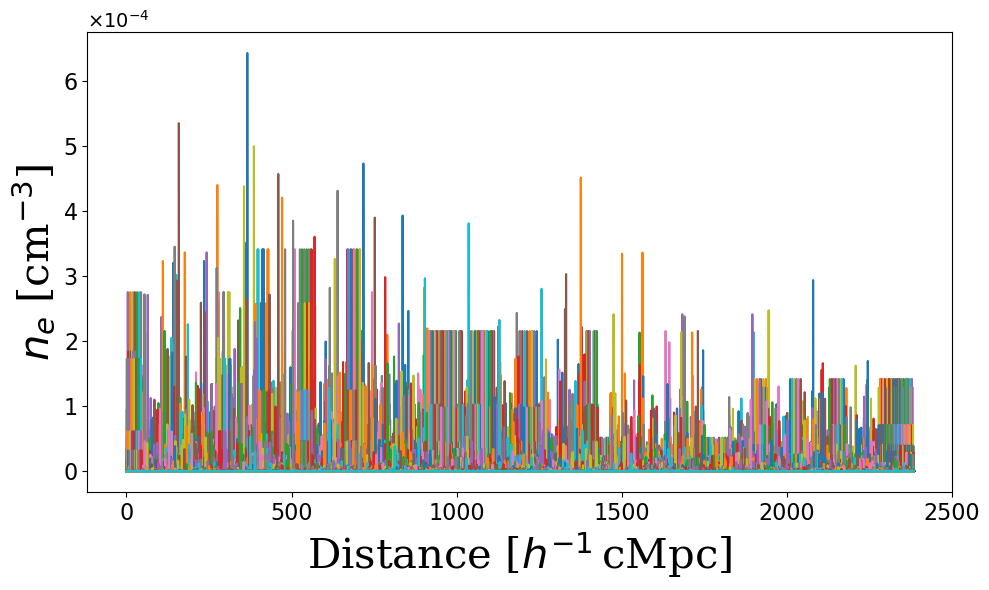

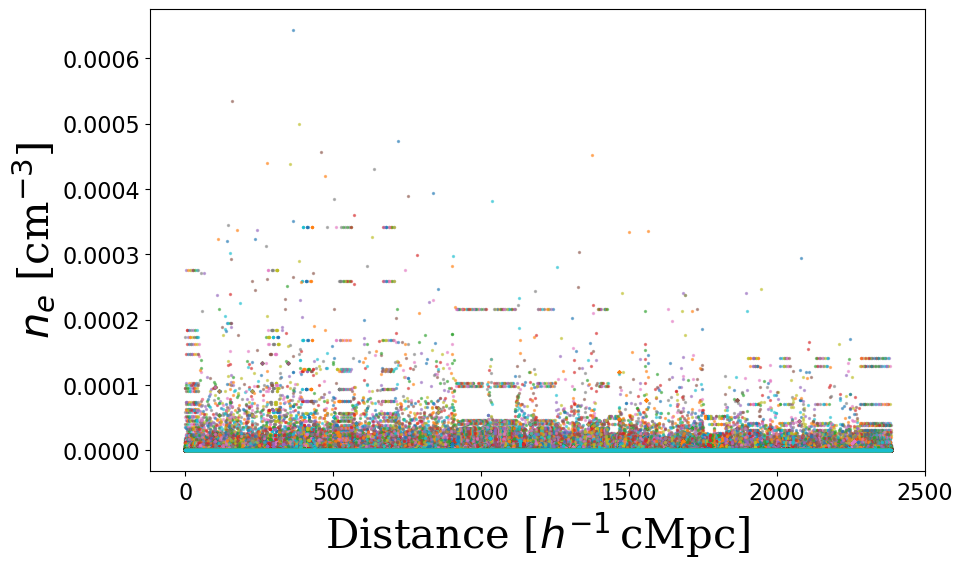

/home/zhaozhang/anaconda3/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


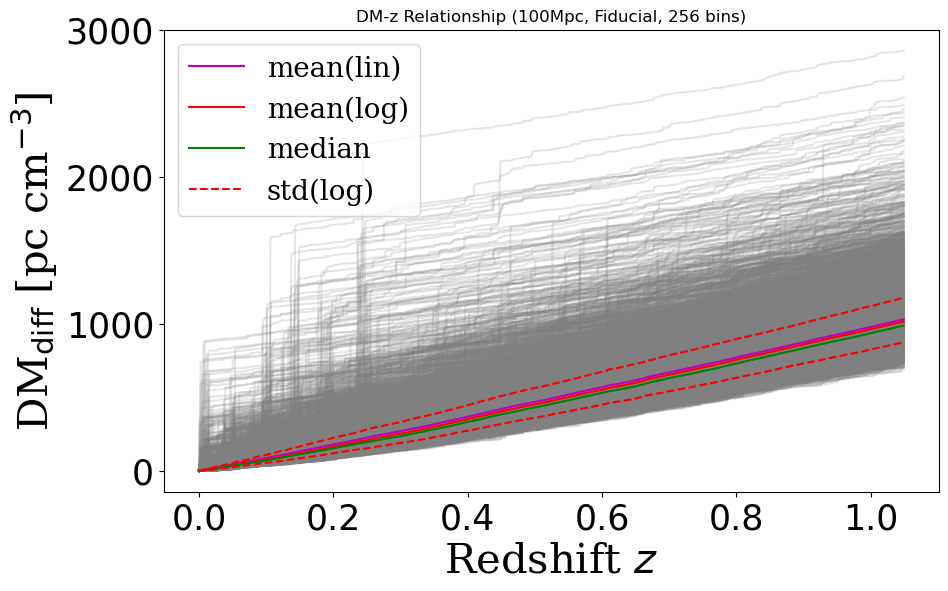

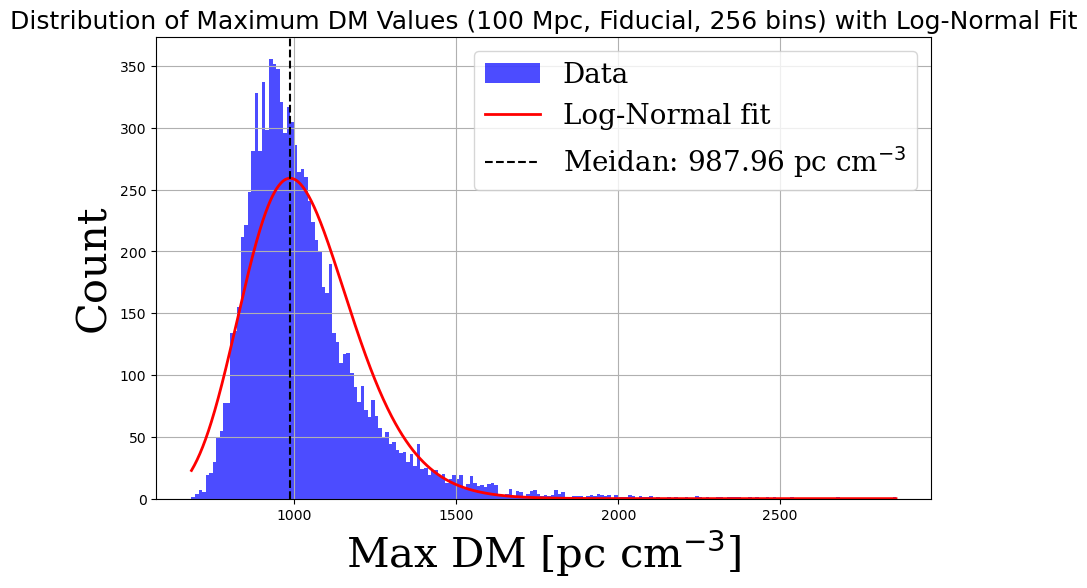

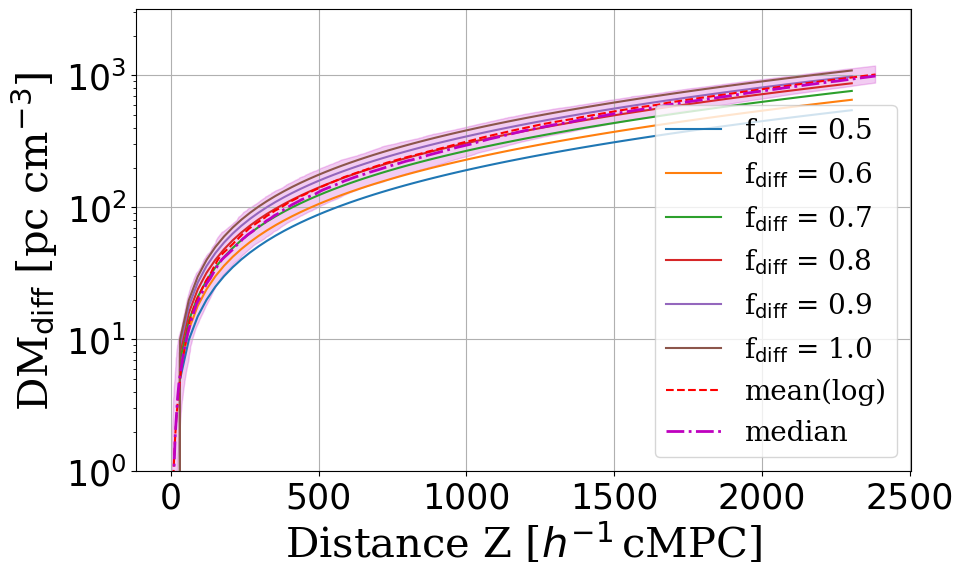

In [2]:
import matplotlib.ticker as ticker
font_label = {
    'family': 'serif',
    'size': 30
}

tick_size = 25

font_legend= {
    'family': 'serif',
    'size': 20
}

font_legend_small= {
    'family': 'serif',
    'size': 16
}

def log_mean_without_zeros(arr):
    # 将数组中的零替换为NaN
    arr[arr == 0] = np.nan
    # 计算对数平均值，忽略NaN值
    log_mean = np.nanmean(np.log(arr), axis=0)
    return np.exp(log_mean)

def linear_mean_without_zeros(arr):
    # 将数组中的零替换为NaN
    arr[arr == 0] = np.nan
    # 计算对数平均值，忽略NaN值
    linear_mean = np.nanmean(arr, axis=0)
    return linear_mean

def median_without_zeros(arr):
    # 将数组中的零替换为NaN
    arr[arr == 0] = np.nan
    # 计算对数平均值，忽略NaN值
    median = np.nanmedian(arr, axis=0)
    return median

def calculate_error_bands(data):
    """
    计算上下两条曲线作为误差范围。

    参数：
    data (numpy.ndarray): 数据数组。

    返回：
    (numpy.ndarray, numpy.ndarray): 返回上限曲线和下限曲线。
    """
    # 在对数空间中计算 percentiles
    data[data == 0] = np.nan
    log_data = np.log(data) 

    # 计算上下限
    percentiles = [16, 84]  # 16th and 84th percentiles
    percentile_values = np.nanpercentile(log_data, percentiles, axis=0)

    # 上下限曲线
    lower_bound_curve = percentile_values[0]
    upper_bound_curve = percentile_values[1]

    return np.exp(lower_bound_curve), np.exp(upper_bound_curve)
def calculate_mean_error(data):
    """
    计算上下两条曲线作为误差范围。

    参数：
    data (numpy.ndarray): 数据数组。

    返回：
    (numpy.ndarray, numpy.ndarray): 返回上限曲线和下限曲线。
    """
    # 在对数空间中计算 percentiles
    data[data == 0] = np.nan
    log_data = np.log(data) 

    mean_log = np.nanmean(log_data, axis=0)
    std_log = np.nanstd(log_data, axis=0)
    sem_log = std_log / np.sqrt(N_los)  # N_los 是 sightlines 数目

    lower_sem = mean_log - sem_log
    upper_sem = mean_log + sem_log

    return np.exp(lower_sem), np.exp(upper_sem)


h = 0.6774
Distance = np.array(Bin_centers_shifted_tot)
ne_LC_shifted_tot_stack = np.stack(ne_LC_shifted_tot)
DM_IGM_LC_tot_stack = np.stack(DM_IGM_LC_tot)
ne_IGM = ne_LC_shifted_tot_stack*h**2
Distance_flat = Distance.flatten()
Redshift = np.array(z_list_center)
Redshift_flat = Redshift.flatten()
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot()
for i in range(LC_num):
    ax.plot(Distance_flat*h, ne_IGM[:,i,:].flatten())
plt.xlabel('Distance [$h^{-1}\,$cMpc]', fontdict=font_label)
plt.ylabel("$n_e$ [cm$^{-3}$]", fontdict=font_label)
plt.xlim(right = 2500)
plt.tick_params(labelsize=16)  
ax = plt.gca()  # 获取当前坐标轴
ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax.yaxis.get_offset_text().set_fontsize(14)  # 可选：调整指数的字体大小
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))  # 强制科学计数法

#plt.title(f"Electron Density Profile ({Boxname}Mpc, {AGN_info}, {Bin_num} bins)")
plt.tight_layout()
plt.savefig(f"{storage_path}/ne_{Boxname}Mpc_{AGN_info}_{Bin_num}_{LC_num}LC.png", bbox_inches='tight', dpi = 400)


fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot()

for i in range(LC_num):
    ax.scatter(Distance_flat*h, ne_IGM[:,i,:].flatten(), s=2, alpha=0.5)  # s 控制点的大小, alpha 控制透明度

plt.xlabel('Distance [$h^{-1}\,$cMpc]', fontdict=font_label)
plt.ylabel("$n_e$ [cm$^{-3}$]", fontdict=font_label)
plt.xlim(right = 2500)
plt.tick_params(labelsize=16)  
plt.savefig(f"{storage_path}/ne_{Boxname}Mpc_{AGN_info}_{Bin_num}_{LC_num}LC_scatter.png")

fig = plt.figure(figsize=(10, 6))

ax = fig.add_subplot()
DM_IGM_N = []
DM_IGM_LC_tot_stack = np.stack(DM_IGM_LC_tot)
DM_IGM = DM_IGM_LC_tot_stack
for i in range(LC_num):
    DM_IGM_N.append(list(DM_IGM[:,i,:].flatten()))
    ax.plot(Redshift_flat , DM_IGM[:,i,:].flatten(), c = "grey", alpha = 0.2)
DM_IGM_N = np.array(DM_IGM_N)
lin_mean_curve = linear_mean_without_zeros(DM_IGM_N)
log_mean_curve = log_mean_without_zeros(DM_IGM_N)
median_curve = median_without_zeros(DM_IGM_N)
std_curve_lower, std_curve_upper = calculate_error_bands(DM_IGM_N)
ax.plot(Redshift_flat, lin_mean_curve, c ="m", label = "mean(lin)")
ax.plot(Redshift_flat, log_mean_curve, c ="r", label = "mean(log)")

ax.plot(Redshift_flat, median_curve, c ="g", label = "median")
ax.plot(Redshift_flat, std_curve_lower, c ="r", linestyle ="--",  label = "std(log)")
ax.plot(Redshift_flat, std_curve_upper, c ="r", linestyle ="--")
plt.xlabel('Redshift $z$', fontdict=font_label)
plt.ylabel("DM$_{\mathrm{diff}}$ [pc cm$^{-3}$]", fontdict=font_label)
#plt.yscale("log")
#plt.xscale("log")
plt.legend(prop = font_legend)
# Set the font size of X-axis and Y-axis ticks
ax.tick_params(axis='x', labelsize=tick_size)  # Adjust the font size of X-axis tick labels
ax.tick_params(axis='y', labelsize=tick_size)  # Adjust the font size of Y-axis tick labels
plt.title(f"DM-z Relationship ({Boxname}Mpc, {AGN_info}, {Bin_num} bins)")
plt.savefig(f"{storage_path}/DM_{Boxname}Mpc_{Bin_num}_{AGN_info}_{LC_num}LC.png")


###################Distribution
# 提取每一行的最后一个元素
max_DM_values = DM_IGM_N[:, -1]

# 对数变换
log_max_DM_values = np.log(max_DM_values)

# 拟合对数正态分布
shape, loc, scale = lognorm.fit(max_DM_values, floc=0)  # 通过固定loc=0来拟合

# 计算标准误差
# 拟合对数正态分布
shape, loc, scale = lognorm.fit(max_DM_values, floc=0)  # 通过固定loc=0来拟合

# 计算标准误差
shape_err = np.std(log_max_DM_values) / np.sqrt(len(log_max_DM_values))
scale_err = np.std(max_DM_values) / np.sqrt(len(max_DM_values))

print(f"Shape parameter: {shape} ± {shape_err}")
print(f"Scale parameter: {scale} ± {scale_err}")

# 创建对数正态分布的x值范围
x = np.linspace(min(max_DM_values), max(max_DM_values), 1000)
DM_max_median = median_without_zeros(max_DM_values)
counts, bins = np.histogram(max_DM_values, bins=200)
bin_width = bins[1] - bins[0]

# 计算拟合的对数正态分布的概率密度函数
pdf = lognorm.pdf(x, shape, loc, scale)
pdf_scaled = pdf * len(max_DM_values) * bin_width  # 缩放 PDF 使其匹配样本数量

# 绘制直方图和拟合曲线
plt.figure(figsize=(10, 6))
plt.hist(max_DM_values, bins=200, color='blue', alpha=0.7, label='Data')  # 绘制直方图
#log10_pdf = np.log10(pdf)
plt.plot(x, pdf_scaled, 'r-', lw=2, label='Log-Normal fit')  # 绘制拟合曲线
plt.axvline(x=DM_max_median, color='k', linestyle='--', label=f'Meidan: {DM_max_median:.2f} pc cm$^{{-3}}$')
plt.xlabel('Max DM [pc cm$^{-3}$]', fontdict=font_label)
plt.ylabel('Count', fontdict=font_label)
plt.title(f'Distribution of Maximum DM Values ({Boxname} Mpc, {AGN_info}, {Bin_num} bins) with Log-Normal Fit', fontsize=18)
plt.legend(prop = font_legend)
plt.grid(True)  # 添加网格线可以使图表更清晰
plt.savefig(f'{storage_path}/N_PD_{Boxname}_{AGN_info}_{LC_num}LC.png', dpi=400)
plt.show()



###################model vs simulaiton
pcTocm = 3.08567758*10**18
# Constants in cgs units


c = 3e10  # Speed of light in cm/s
H0 = 67.66 * 1e5 / 3.086e24  # Hubble constant in 1/s (converted from km/s/Mpc to cm/s/cm)
Omega_b = 0.04889
Omega_m = 0.309
Omega_Lambda = 0.69
mp = 1.67e-24  # Proton mass in g
G = 6.67430e-8  # Gravitational constant in cm^3 g^-1 s^-2
Y_H = 0.75
Y_He = 0.25
# 宇宙学参数

# 计算共动距离和尺度因子的函数
def comoving_distance(z):
    H_0 = 67.66  # 哈勃常数，单位为 km/s/Mpc
    c = 299792.458  # 光速，单位为 km/s
    integrand = lambda zp: 1.0 / np.sqrt(Omega_m * (1.0+zp)**3 + Omega_Lambda)
    integral, _ = quad(integrand, 0, z)
    return c/H_0 * integral
# Function for chi_e (ionization fraction) - assuming fully ionized
def chi_e_H(z):
    return 1.0

def chi_e_He(z):
    return 1.0

# Integrand function for DM_IGM calculation
def integrand(z):
    return (Y_H * chi_e_H(z) + Y_He * chi_e_He(z) / 2) * (1 + z) / np.sqrt(Omega_m * (1 + z)**3 + Omega_Lambda)

# Function to calculate DM_IGM
def calculate_DM_IGM_model(f_IGM, z):
    integral, _ = quad(integrand, 0, z)
    DM_IGM = (3 * c * H0 * Omega_b * f_IGM / (8 * np.pi * G * mp)) * integral / pcTocm  # convert from cm^-2 to pc cm^-3
    return DM_IGM

# Given redshift data
redshifts = np.linspace(0, 1.0, 100)
Distances =  np.array([comoving_distance(z) for z in redshifts])
# Range of f_IGM values to test
f_IGM_values = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

# Plotting
plt.figure(figsize=(10, 6))
for f_IGM in f_IGM_values:
    DM_values = [calculate_DM_IGM_model(f_IGM, z) for z in redshifts]
    plt.plot(Distances*h , DM_values, label=f'f$_{{\mathrm{{diff}}}}$ = {f_IGM}')
# Calculate midpoints
midpoints = (redshifts[:-1] + redshifts[1:]) / 2

plt.plot(Distance_flat*h,  log_mean_curve, c ="r",linestyle="--", label = "mean(log)")
plt.plot(Distance_flat*h,  median_curve, c ="m",linestyle="-.", linewidth = 2,  label = "median")
#plt.plot(Distance_flat,  np.log10(std_curve_lower), c ="k", linestyle ="--",  label = "std(log)")
#plt.plot(Distance_flat,  np.log10(std_curve_upper), c ="k", linestyle ="--")

plt.fill_between(Distance_flat*h, std_curve_lower, std_curve_upper, color="m", alpha=0.2)
plt.xlabel('Distance Z [$h^{-1}\,$cMPC]', fontdict=font_label)
plt.ylabel('DM$_{\mathrm{diff}}$ [pc cm$^{-3}$]', fontdict=font_label)
plt.tick_params(labelsize=tick_size)
plt.yscale("log")
#x_ticks = [0, 250, 500, 750, 1000, 1500, 2000]
#plt.xticks(x_ticks)
#plt.xscale("log")
plt.legend(prop=font_legend)
#plt.xlim(0,400)
plt.ylim(1e0,10**3.5)
#plt.title(f'log10 DM$_{{IGM}}$ vs Redshift for different f$_{{IGM}}$ values ({Boxname}Mpc, {AGN_info}, {Bin_num} bins)')
plt.grid(True)
plt.savefig(f"{storage_path}/DM_f_IGM_1400_{Boxname}_{AGN_info}_LC{LC_num}.png",dpi = 400)
plt.show()



In [ ]:

std_mean_lower, std_mean_upper = calculate_mean_error(DM_IGM_N)

print(std_mean_lower, std_mean_upper)

## Diagnostic Profiles Along the Connected Light Cone

These plots provide a first diagnostic view of the connected boxes by showing the electron number density $n_e$ and the cumulative DM behaviour along all constructed sightlines. This is the quickest place to check whether the box stitching behaves smoothly before moving to the summary panels.


/tmp/ipykernel_1006230/2595668466.py:66: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(f"{storage_path}/DM_{Boxname}Mpc_{Bin_num}_{AGN_info}_{LC_num}LC_limited.png", bbox_inches='tight', dpi = 400)


Shape parameter: 0.42759196046202474 ± 0.0042759196046202475
Scale parameter: 76.80081201612091 ± 0.6234833382870945


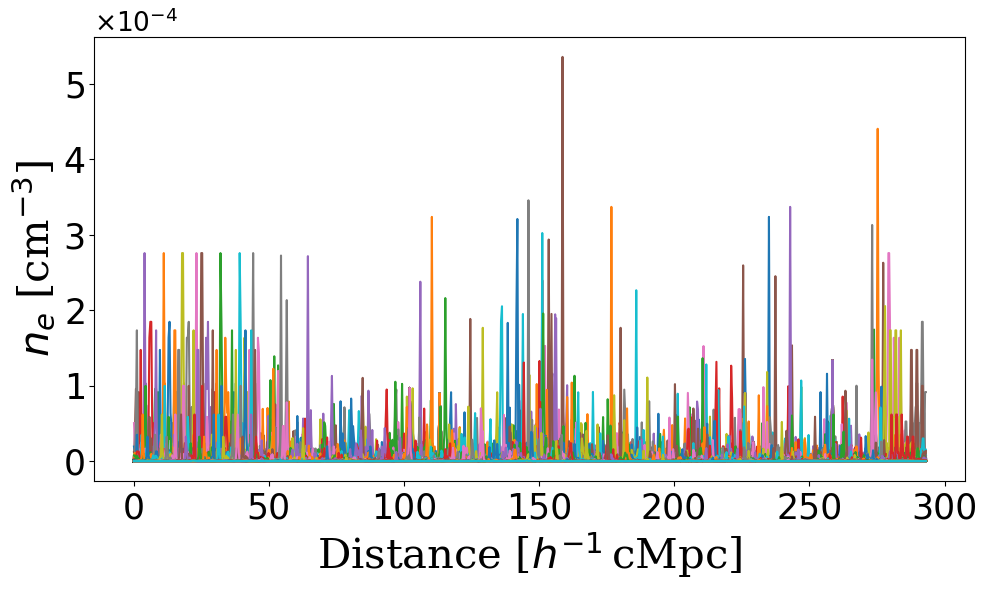

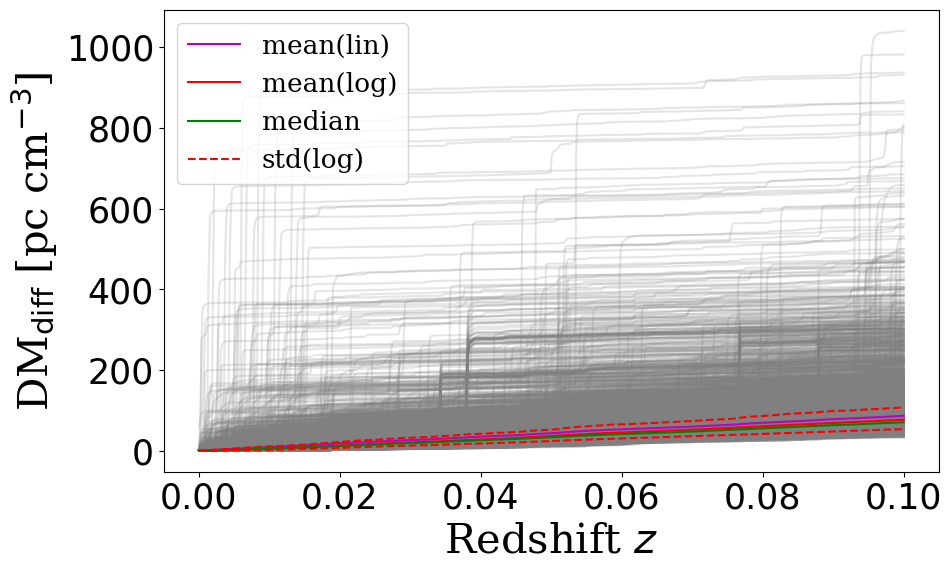

<Figure size 1000x600 with 0 Axes>

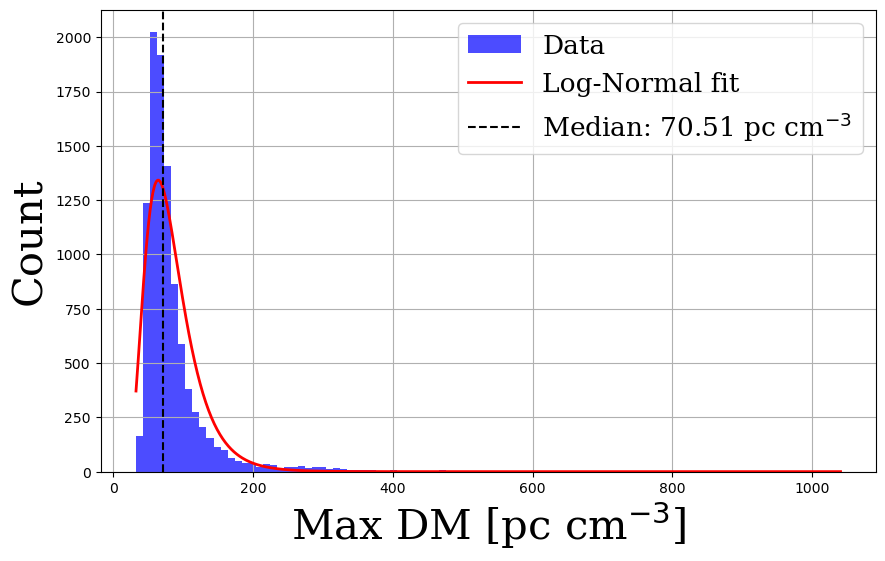

At z_0 = 0.1:
f_IGM (median) = 0.704
f_IGM (lower)  = 0.534
f_IGM (upper)  = 1.070


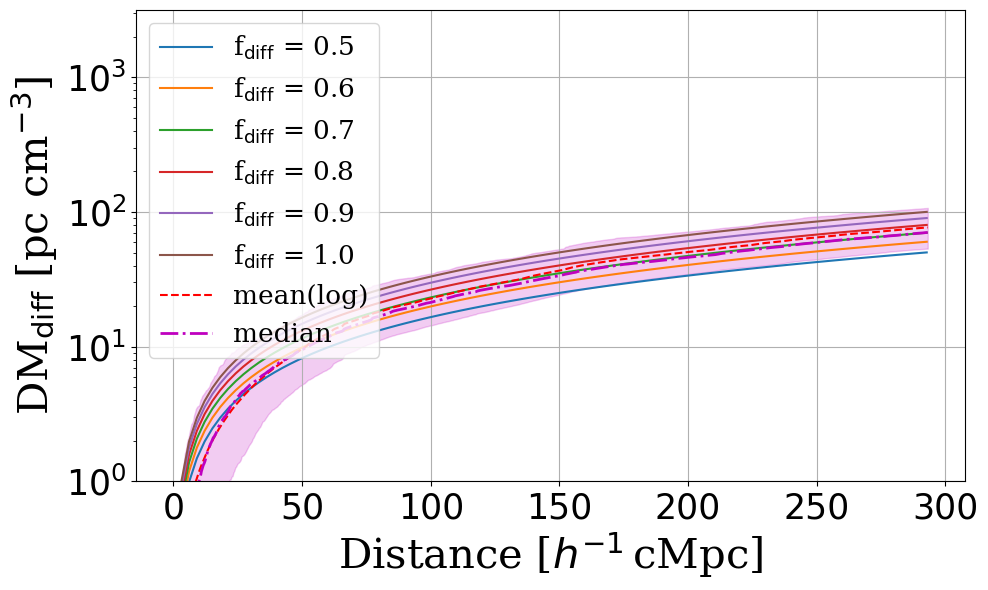

In [3]:
font_legend= {
    'family': 'serif',
    'size': 19
}

from scipy.interpolate import interp1d
################# 限制到 2000 Mpc 的距离范围
#z_0 = 1.041
z_0 = 0.1
distance_limit = comoving_distance(z_0)
#distance_limit = 3600  # Mpc
distance_mask = Distance_flat <= distance_limit
redshift_mask = Redshift_flat[distance_mask]  # 同步对红移限制

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot()

# 电子数密度图
for i in range(LC_num):
    ax.plot(Distance_flat[distance_mask]*h, ne_IGM[:, i, :].flatten()[distance_mask])

plt.xlabel('Distance [$h^{-1}\,$cMpc]', fontdict=font_label)
plt.ylabel("$n_e$ [cm$^{-3}$]", fontdict=font_label)
if z_0 == 1.041:
    plt.xlim(right = 2500)
plt.tick_params(labelsize=tick_size)
ax = plt.gca()  # 获取当前坐标轴
ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax.yaxis.get_offset_text().set_fontsize(19)  # 可选：调整指数的字体大小
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))  # 强制科学计数法

#plt.title(f"Electron Density Profile ({Boxname}Mpc, {AGN_info}, {Bin_num} bins)")
plt.tight_layout()
plt.savefig(f"{storage_path}/ne_{Boxname}Mpc_{AGN_info}_{Bin_num}_{LC_num}LC.png", bbox_inches='tight', dpi = 400)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot()

# 限制后的 DM-z 关系图
DM_IGM_N = []
for i in range(LC_num):
    DM_flat = DM_IGM[:, i, :].flatten()[distance_mask]
    ax.plot(redshift_mask, DM_flat, c="grey", alpha=0.2)
    DM_IGM_N.append(DM_flat)

DM_IGM_N = np.array(DM_IGM_N)
lin_mean_curve = linear_mean_without_zeros(DM_IGM_N)
log_mean_curve = log_mean_without_zeros(DM_IGM_N)
median_curve = median_without_zeros(DM_IGM_N)
std_curve_lower, std_curve_upper = calculate_error_bands(DM_IGM_N)

ax.plot(redshift_mask, lin_mean_curve, c="m", label="mean(lin)")
ax.plot(redshift_mask, log_mean_curve, c="r", label="mean(log)")
ax.plot(redshift_mask, median_curve, c="g", label="median")
ax.plot(redshift_mask, std_curve_lower, c="r", linestyle="--", label="std(log)")
ax.plot(redshift_mask, std_curve_upper, c="r", linestyle="--")

plt.xlabel('Redshift $z$', fontdict=font_label)
plt.ylabel("DM$_{\mathrm{diff}}$ [pc cm$^{-3}$]", fontdict=font_label)
#plt.yscale("log")
#plt.xscale("log")
plt.legend(prop=font_legend)
ax.tick_params(axis='x', labelsize=tick_size)  # Adjust the font size of X-axis tick labels
ax.tick_params(axis='y', labelsize=tick_size)  # Adjust the font size of Y-axis tick labels
#plt.title(f"DM-z Relationship (up to {distance_limit} Mpc) ({Boxname}Mpc, {AGN_info}, {Bin_num} bins)")
plt.savefig(f"{storage_path}/DM_{Boxname}Mpc_{Bin_num}_{AGN_info}_{LC_num}LC_limited.png", bbox_inches='tight', dpi = 400)

fig = plt.figure(figsize=(10, 6))
# 提取每一行的最后一个元素
max_DM_values = DM_IGM_N[:, -1]

# 对数变换
log_max_DM_values = np.log(max_DM_values)

# 拟合对数正态分布
shape, loc, scale = lognorm.fit(max_DM_values, floc=0)  # 通过固定loc=0来拟合

# 计算标准误差
# 拟合对数正态分布
shape, loc, scale = lognorm.fit(max_DM_values, floc=0)  # 通过固定loc=0来拟合

# 计算标准误差
shape_err = np.std(log_max_DM_values) / np.sqrt(len(log_max_DM_values))
scale_err = np.std(max_DM_values) / np.sqrt(len(max_DM_values))

print(f"Shape parameter: {shape} ± {shape_err}")
print(f"Scale parameter: {scale} ± {scale_err}")

# 创建对数正态分布的x值范围
x = np.linspace(min(max_DM_values), max(max_DM_values), 1000)
DM_max_median = median_without_zeros(max_DM_values)
counts, bins = np.histogram(max_DM_values, bins=100)
bin_width = bins[1] - bins[0]

# 计算拟合的对数正态分布的概率密度函数
pdf = lognorm.pdf(x, shape, loc, scale)
pdf_scaled = pdf * len(max_DM_values) * bin_width  # 缩放 PDF 使其匹配样本数量

# 绘制直方图和拟合曲线
plt.figure(figsize=(10, 6))
plt.hist(max_DM_values, bins=100, color='blue', alpha=0.7, label='Data')  # 绘制直方图
#log10_pdf = np.log10(pdf)
plt.plot(x, pdf_scaled, 'r-', lw=2, label='Log-Normal fit')  # 绘制拟合曲线
#plt.yscale("log")
plt.axvline(x=DM_max_median, color='k', linestyle='--', label=f'Median: {DM_max_median:.2f} pc cm$^{{-3}}$')
plt.xlabel('Max DM [pc cm$^{-3}$]', fontdict=font_label)
plt.ylabel('Count', fontdict=font_label)
#plt.title(f'Distribution of Maximum DM Values ({Boxname} Mpc, {AGN_info}, {Bin_num} bins) with Log-Normal Fit', fontsize=18)
plt.legend(prop = font_legend)
plt.grid(True)  # 添加网格线可以使图表更清晰
plt.savefig(f'{storage_path}/N_PD_{Boxname}_{AGN_info}_{LC_num}LC_limited.png', dpi=400)
plt.show()


pcTocm = 3.08567758*10**18
# Constants in cgs units


c = 3e10  # Speed of light in cm/s
H0 = 67.74 * 1e5 / 3.086e24  # Hubble constant in 1/s (converted from km/s/Mpc to cm/s/cm)
Omega_b = 0.04889
Omega_m = 0.3099
Omega_Lambda = 0.6901
mp = 1.67e-24  # Proton mass in g
G = 6.67430e-8  # Gravitational constant in cm^3 g^-1 s^-2
Y_H = 0.75
Y_He = 0.25
# 宇宙学参数

# 计算共动距离和尺度因子的函数
def comoving_distance(z):
    H_0 = 67.74  # 哈勃常数，单位为 km/s/Mpc
    c = 299792.458  # 光速，单位为 km/s
    integrand = lambda zp: 1.0 / np.sqrt(Omega_m * (1.0+zp)**3 + Omega_Lambda)
    integral, _ = quad(integrand, 0, z)
    return c/H_0 * integral
# Function for chi_e (ionization fraction) - assuming fully ionized
def chi_e_H(z):
    return 1.0

def chi_e_He(z):
    return 1.0

# Integrand function for DM_IGM calculation
def integrand(z):
    return (Y_H * chi_e_H(z) + Y_He * chi_e_He(z) / 2) * (1 + z) / np.sqrt(Omega_m * (1 + z)**3 + Omega_Lambda)

# Function to calculate DM_IGM
def calculate_DM_IGM_model(f_IGM, z):
    integral, _ = quad(integrand, 0, z)
    DM_IGM = (3 * c * H0 * Omega_b * f_IGM / (8 * np.pi * G * mp)) * integral / pcTocm  # convert from cm^-2 to pc cm^-3
    return DM_IGM

# Given redshift data
redshifts = np.linspace(0, z_0, 200)
Distances =  np.array([comoving_distance(z) for z in redshifts])
# Range of f_IGM values to test
f_IGM_values = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

# 计算红移和距离的网格
redshifts = np.linspace(0, z_0, 100)
Distances = np.array([comoving_distance(z) for z in redshifts])

# 计算不同 f_IGM 下的 DM 值
DM_at_z0 = {}
for f_IGM in f_IGM_values:
    DM_at_z0[f_IGM] = calculate_DM_IGM_model(f_IGM, z_0)


# 插值函数: DM -> f_IGM
f_IGM_array = np.array(f_IGM_values)
DM_at_z0_array = np.array(list(DM_at_z0.values()))
interp_model = interp1d(DM_at_z0_array, f_IGM_array, kind='linear', fill_value="extrapolate")

# 插值计算 f_IGM 和误差范围
median_DM_at_z0 = median_curve[-1]  # z_0 处的中位 DM
lower_DM_at_z0 = std_curve_lower[-1]  # 1-sigma 下界
upper_DM_at_z0 = std_curve_upper[-1]  # 1-sigma 上界

f_IGM_median = interp_model(median_DM_at_z0)
f_IGM_lower = interp_model(lower_DM_at_z0)  
f_IGM_upper = interp_model(upper_DM_at_z0)

# 输出结果
print(f"At z_0 = {z_0}:")
print(f"f_IGM (median) = {f_IGM_median:.3f}")
print(f"f_IGM (lower)  = {f_IGM_lower:.3f}")
print(f"f_IGM (upper)  = {f_IGM_upper:.3f}")
# Plotting
Distances_mask = Distances <= np.max(Distance_flat[distance_mask])
plt.figure(figsize=(10, 6))
for f_IGM in f_IGM_values:
    DM_values = np.array([calculate_DM_IGM_model(f_IGM, z) for z in redshifts])
    plt.plot(Distances[Distances_mask]*h , DM_values[Distances_mask], label=f'f$_{{\mathrm{{diff}}}}$ = {f_IGM}')
# Calculate midpoints
midpoints = (redshifts[:-1] + redshifts[1:]) / 2

plt.plot(Distance_flat[distance_mask]*h,  log_mean_curve, c ="r",linestyle="--", label = "mean(log)")
plt.plot(Distance_flat[distance_mask]*h,  median_curve, c ="m",linestyle="-.", linewidth = 2,  label = "median")
#plt.plot(Distance_flat,  np.log10(std_curve_lower), c ="k", linestyle ="--",  label = "std(log)")
#plt.plot(Distance_flat,  np.log10(std_curve_upper), c ="k", linestyle ="--")

plt.fill_between(Distance_flat[distance_mask]*h, std_curve_lower, std_curve_upper, color="m", alpha=0.2)
plt.tick_params(labelsize=tick_size)
plt.xlabel('Distance [$h^{-1}\,$cMpc]', fontdict=font_label)
plt.ylabel('DM$_{\mathrm{diff}}$ [pc cm$^{-3}$]', fontdict=font_label)
plt.yscale("log")
#plt.xscale("log")
plt.legend(prop= font_legend)
#plt.xlim(right=2500)
if z_0 == 1.0:
    plt.xlim(right = 2500)
plt.ylim(1e0,10**3.5)
#plt.title(f'log10 DM$_{{IGM}}$ vs Redshift for different f$_{{IGM}}$ values ({Boxname}Mpc, {AGN_info}, {Bin_num} bins)')
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{storage_path}/DM_f_IGM_1400_{Boxname}_{AGN_info}_{LC_num}LC.png",dpi = 400)
plt.show()



In [7]:

Distance_flat[distance_mask]*h

array([1.25172137e-01, 3.75516412e-01, 6.25860686e-01, ...,
       2.33802807e+03, 2.33823565e+03, 2.33844324e+03])

## Runtime Parameters for the Box-Connection Calculation

This panel records the command-line inputs and default values that control the light-cone construction, including the level, AGN flag, transverse sampling, LOS binning, and filtering threshold.


In [4]:
# 提取参数
level_input = sys.argv[1] if len(sys.argv) > 1 else default_level_input
AGN_name = sys.argv[2] if len(sys.argv) > 2 else default_AGN_name
X_num = get_int_arg(3, default_X_num)
Y_num = get_int_arg(4, default_Y_num)
LC_bins = get_int_arg(5, default_LC_bins)
threshold = get_float_arg(6, default_threshold)

# 继续脚本内容
print(f"Level Input: {level_input}")
print(f"AGN Name: {AGN_name}")
print(f"X Num: {X_num}")
print(f"Y Num: {Y_num}")
print(f"LC Bins: {LC_bins}")
print(f"Threshold: {threshold}")

Level Input: --ip=127.0.0.1
AGN Name: --stdin=9013
X Num: 70
Y Num: 70
LC Bins: 400
Threshold: 0.0001


In [17]:
distance_limit = 2000  # Mpc
distance_mask = Distance_flat <= distance_limit
Distance_flat <= distance_limit

array([ True,  True,  True, ..., False, False, False])

## Full Light-Cone DM Distribution

This panel visualises the full connected light cone by stacking all LOS trajectories in the $\mathrm{DM}$-$z$ plane and comparing them with ensemble summary curves. The companion side panel shows the final DM distribution at the maximum redshift covered by the stitched boxes.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm
from matplotlib.gridspec import GridSpec

# 创建主图和旋转后的分布图的布局
fig = plt.figure(figsize=(12, 7))
gs = GridSpec(1, 2, width_ratios=[2, 1.35], wspace=0.02)  # 主图占1.5份宽度，分布图占1份宽度

# 主图
ax_main = fig.add_subplot(gs[0])
DM_IGM_N = []
DM_IGM_LC_tot_stack = np.stack(DM_IGM_LC_tot)
DM_IGM = DM_IGM_LC_tot_stack
for i in range(LC_num):
    DM_IGM_N.append(list(DM_IGM[:, i, :].flatten()))
    ax_main.plot(Redshift_flat, DM_IGM[:, i, :].flatten(), c="grey", alpha=0.1)
DM_IGM_N = np.array(DM_IGM_N)
lin_mean_curve = linear_mean_without_zeros(DM_IGM_N)
log_mean_curve = log_mean_without_zeros(DM_IGM_N)
median_curve = median_without_zeros(DM_IGM_N)
std_curve_lower, std_curve_upper = calculate_error_bands(DM_IGM_N)
ax_main.plot(Redshift_flat, lin_mean_curve, c="m", label="mean(lin)")
ax_main.plot(Redshift_flat, log_mean_curve, c="r", label="mean(log)")
ax_main.plot(Redshift_flat, median_curve, c="g", label="median")
ax_main.plot(Redshift_flat, std_curve_lower, c="r", linestyle="--", label="std(log)")
ax_main.plot(Redshift_flat, std_curve_upper, c="r", linestyle="--")
ax_main.set_xlabel('Redshift $z$', fontdict=font_label)
ax_main.set_ylabel("DM$_{\mathrm{diff}}$ [pc cm$^{-3}$]", fontdict=font_label)
#ax_main.set_yscale("log")
#ax_main.set_xscale("log")
ax_main.set_xlim(right = 1.09)
#ax_main.set_ylim(top = 3500)
ax_main.legend(prop=font_legend)
ax_main.tick_params(axis='x', labelsize=tick_size)
ax_main.tick_params(axis='y', labelsize=tick_size)
#ax_main.set_title(f"DM-z Relationship ({Boxname}Mpc, {AGN_info}, {Bin_num} bins)")

# 提取每一行的最后一个元素用于分布图
max_DM_values = DM_IGM_N[:, -1]
log_max_DM_values = np.log(max_DM_values)
shape, loc, scale = lognorm.fit(max_DM_values, floc=0)

# 创建对数正态分布的 x 值范围
x = np.linspace(min(max_DM_values), max(max_DM_values), 1000)
pdf = lognorm.pdf(x, shape, loc, scale)
# 计算直方图的 bin 宽度，用于缩放 PDF
counts, bins = np.histogram(max_DM_values, bins=1000)
bin_width = bins[1] - bins[0]

# 计算缩放后的 PDF
pdf_scaled = pdf * len(max_DM_values) * bin_width  # 缩放 PDF 到样本数量
density_on = True
# 右侧分布图
ax_dist = fig.add_subplot(gs[1], sharey=ax_main)
ax_dist.hist(max_DM_values, bins=50, color='blue', density = density_on, alpha=0.7, orientation='horizontal', label='Data')  # 去掉 density=True
ax_dist.plot(pdf, x, 'r-', lw=2, label='Log-Normal fit')  # 绘制缩放后的拟合曲线
ax_dist.axhline(y=DM_max_median, color='k', linestyle='--', label=f'Median: {DM_max_median:.2f} pc cm$^{{-3}}$')
ax_dist.set_xlabel('PDF', fontdict=font_label)  # 将 Density 改为 Count
ax_dist.tick_params(axis='x', labelsize=tick_size)
ax_dist.legend(prop=font_legend_small)
ax_dist.grid(True)
#plt.ylim(bottom = 10**1)
plt.setp(ax_dist.get_yticklabels(), visible=False)  # 隐藏分布图的 Y 轴标签
ax_dist.set_xticks([0,0.002,0.004], ["0", "0.002", "0.004"])  #  直接修正参数格式

# 保存图像
plt.savefig(f'{storage_path}/Combined_DM_Distribution_{Boxname}_{AGN_info}_{Bin_num}_LC{LC_num}.png', bbox_inches='tight', dpi=400)
plt.show()


/tmp/ipykernel_212358/1126091421.py:68: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(f'{storage_path}/Combined_DM_Distribution_{Boxname}_{AGN_info}_{Bin_num}_LC{LC_num}.png', bbox_inches='tight', dpi=400)


## Export of Light-Cone Products to HDF5

The datasets written here preserve the redshift grid, comoving distance grid, LOS-resolved DM and $n_e$ series, and the DM probability distributions evaluated at several redshift cuts. This makes the notebook outputs reusable in later analysis and plotting scripts.


Processing z_0 = 0.1
Processing z_0 = 0.2
Processing z_0 = 0.3
Processing z_0 = 0.4
Processing z_0 = 0.5
Processing z_0 = 0.6
Processing z_0 = 0.7
Processing z_0 = 0.8
Processing z_0 = 0.9
Processing z_0 = 1.0


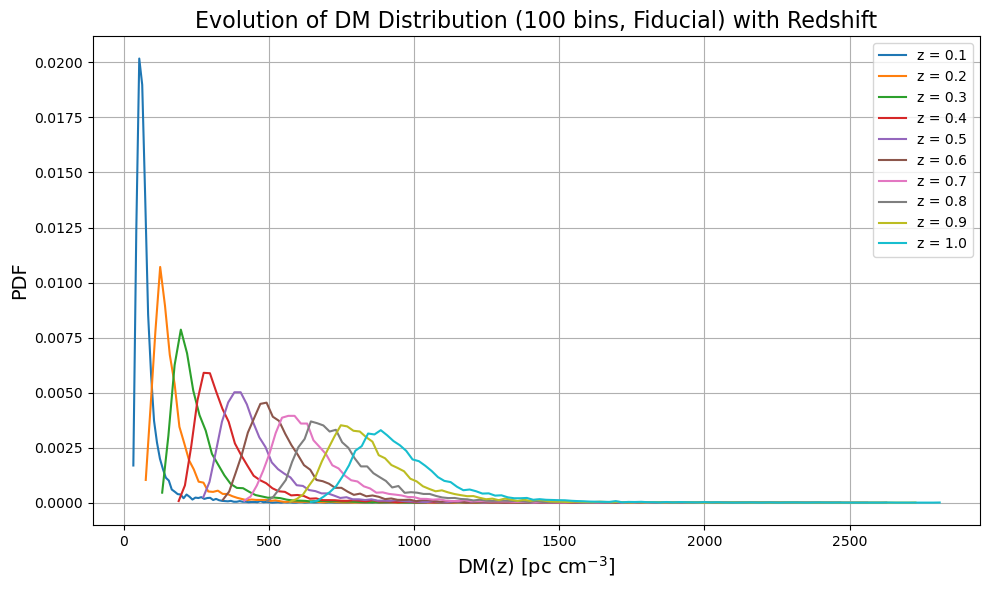

In [6]:
import h5py
import numpy as np
from scipy.stats import lognorm
# 打开或创建 HDF5 文件
with h5py.File(f"{storage_path}/DM_diff_analysis_{AGN_info}.hdf5", "w") as f:
    # 第一部分：保存每条视线对应的 DM 和红移
    #f.create_dataset("DM_IGM_per_LOS", data=DM_IGM_LC_tot_stack)  # shape: (snapshot_num, LC_num, n_bins)
    f.create_dataset("Redshift", data=Redshift_flat)
    f.create_dataset("Distance", data=Distance_flat)
    f["Distance"].attrs["unit"] = "h^-1 cMpc"
    DM_group = f.create_group("DM_diff_Lines")
    DM_group.attrs["unit"] = "pc cm^-3"  # DM 的单位
    ne_group = f.create_group("ne_Lines")
    ne_group.attrs["unit"] = "cm^-3"    
    for i in range(DM_IGM.shape[1]):  # 遍历所有视线方向
        DM_line = DM_IGM[:, i, :].flatten()
        DM_group.create_dataset(f"LOS_{i}", data=DM_line)
    for i in range(ne_IGM.shape[1]):  # 遍历所有视线方向
        ne_line = ne_IGM[:, i, :].flatten()
        ne_group.create_dataset(f"LOS_{i}", data=ne_line)
    # 第二部分：遍历不同 z_0 保存 DM 分布 PDF 和对应 max_DM_values
    z_list_save = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    group_pdf = f.create_group("DM_PDFs_by_redshift")
    
    for z_0 in z_list_save:
        print(f"Processing z_0 = {z_0}")
        distance_limit = comoving_distance(z_0)
        distance_mask = Distance_flat <= distance_limit
        redshift_mask = Redshift_flat[distance_mask]

        DM_IGM_N_masked = []
        for i in range(LC_num):
            DM_flat = DM_IGM[:, i, :].flatten()[distance_mask]
            DM_IGM_N_masked.append(DM_flat)
        DM_IGM_N_masked = np.array(DM_IGM_N_masked)

        max_DM_values = DM_IGM_N_masked[:, -1]
        log_max_DM_values = np.log(max_DM_values[max_DM_values > 0])  # avoid log(0)

        # 拟合3
        shape, loc, scale = lognorm.fit(max_DM_values, floc=0)
        x = np.linspace(min(max_DM_values), max(max_DM_values), 100)
        PDF, bins = np.histogram(max_DM_values, bins=100, density = True)
        Count, bins = np.histogram(max_DM_values, bins=100)
        bin_width = bins[1] - bins[0]
        pdf = lognorm.pdf(x, shape, loc, scale)
        pdf_scaled = pdf * len(max_DM_values) * bin_width

        # 存入子组
        z_group = group_pdf.create_group(f"z_{z_0}")
        z_group.create_dataset("All_DMs_at_z", data=max_DM_values)
        z_group.create_dataset("DM_at_z_binned", data=x)
        z_group.create_dataset("Count", data=Count)
        z_group.create_dataset("PDF", data=PDF)
        z_group.create_dataset("count_lognormal_fit_binned", data=pdf_scaled)
        z_group.create_dataset("pdf_lognormal_fit_binned", data=pdf)
        
        z_group.attrs["shape"] = shape
        z_group.attrs["loc"] = loc
        z_group.attrs["scale"] = scale




# 打开已保存的文件
with h5py.File(f"{storage_path}/DM_diff_analysis_{AGN_info}.hdf5", "r") as f:
    group = f["DM_PDFs_by_redshift"]
    z_list = sorted([float(key.split("_")[1]) for key in group.keys()])
    
    plt.figure(figsize=(10, 6))
    
    for z in z_list:
        z_group = group[f"z_{z}"]
        x = z_group["DM_at_z_binned"][:]
        pdf = z_group["PDF"][:]
        plt.plot(x, pdf, label=f"z = {z:.1f}")
    
    plt.xlabel("DM(z) [pc cm$^{-3}$]", fontsize=14)
    plt.ylabel("PDF", fontsize=14)
    plt.title(f"Evolution of DM Distribution (100 bins, {AGN_info}) with Redshift", fontsize=16)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"{storage_path}/DM_max_PDF_evolution.png", dpi=300)
    plt.show()


## Foreground-Limited Light-Cone View ($d_{\mathrm{com}} < 2000\ \mathrm{Mpc}$)

This panel repeats the DM analysis after truncating the light cone to the nearby foreground volume. It is useful for isolating the contribution from the first $\sim 2000$ comoving Mpc and for comparing the low-redshift structure against the full light-cone result.


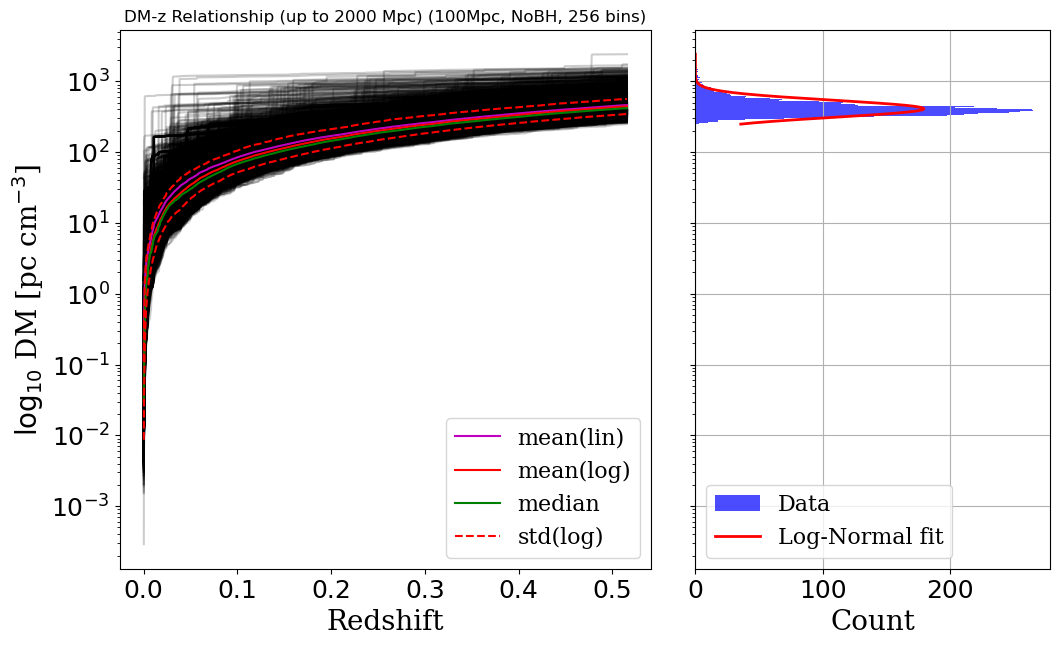

In [ ]:
# 创建主图和旋转后的分布图的布局
fig = plt.figure(figsize=(12, 7))
gs = GridSpec(1, 2, width_ratios=[1.5, 1], wspace=0.1)  # 主图占1.5份宽度，分布图占1份宽度

# 限制到 2000 Mpc 的距离范围
distance_limit = 2000  # Mpc
distance_mask = Distance_flat <= distance_limit
redshift_mask = Redshift_flat[distance_mask]  # 同步对红移限制

# 主图
ax_main = fig.add_subplot(gs[0])
DM_IGM_N = []
DM_IGM_LC_tot_stack = np.stack(DM_IGM_LC_tot)
DM_IGM = DM_IGM_LC_tot_stack
for i in range(LC_num):
    DM_flat = DM_IGM[:, i, :].flatten()[distance_mask]
    ax_main.plot(redshift_mask, DM_flat, c="k", alpha=0.2)
    DM_IGM_N.append(DM_flat)

DM_IGM_N = np.array(DM_IGM_N)
lin_mean_curve = linear_mean_without_zeros(DM_IGM_N)
log_mean_curve = log_mean_without_zeros(DM_IGM_N)
median_curve = median_without_zeros(DM_IGM_N)
std_curve_lower, std_curve_upper = calculate_error_bands(DM_IGM_N)
ax_main.plot(redshift_mask, lin_mean_curve, c="m", label="mean(lin)")
ax_main.plot(redshift_mask, log_mean_curve, c="r", label="mean(log)")
ax_main.plot(redshift_mask, median_curve, c="g", label="median")
ax_main.plot(redshift_mask, std_curve_lower, c="r", linestyle="--", label="std(log)")
ax_main.plot(redshift_mask, std_curve_upper, c="r", linestyle="--")
ax_main.set_xlabel('Redshift', fontdict=font_label)
ax_main.set_ylabel("$\mathrm{log}_{10}$ DM [pc cm$^{-3}$]", fontdict=font_label)
ax_main.set_yscale("log")
ax_main.legend(prop=font_legend)
ax_main.tick_params(axis='x', labelsize=tick_size)
ax_main.tick_params(axis='y', labelsize=tick_size)
ax_main.set_title(f"DM-z Relationship (up to {distance_limit} Mpc) ({Boxname}Mpc, {AGN_info}, {Bin_num} bins)")

# 提取每一行的最后一个元素用于分布图
max_DM_values = DM_IGM_N[:, -1]
log_max_DM_values = np.log(max_DM_values)
shape, loc, scale = lognorm.fit(max_DM_values, floc=0)

# 创建对数正态分布的 x 值范围
x = np.linspace(min(max_DM_values), max(max_DM_values), 1000)

# 计算直方图的 bin 宽度，用于缩放 PDF
counts, bins = np.histogram(max_DM_values, bins=200)
bin_width = bins[1] - bins[0]

# 计算缩放后的 PDF
pdf = lognorm.pdf(x, shape, loc, scale)
pdf_scaled = pdf * len(max_DM_values) * bin_width  # 缩放 PDF 到样本数量

# 右侧分布图
ax_dist = fig.add_subplot(gs[1], sharey=ax_main)
ax_dist.hist(max_DM_values, bins=200, color='blue', alpha=0.7, orientation='horizontal', label='Data')  # 去掉 density=True
ax_dist.plot(pdf_scaled, x, 'r-', lw=2, label='Log-Normal fit')  # 绘制缩放后的拟合曲线
ax_dist.set_xlabel('Count', fontdict=font_label)  # 将 Density 改为 Count
ax_dist.tick_params(axis='x', labelsize=tick_size)
ax_dist.legend(prop=font_legend)
ax_dist.grid(True)
plt.setp(ax_dist.get_yticklabels(), visible=False)  # 隐藏分布图的 Y 轴标签

# 保存图像
plt.savefig(f'{storage_path}/Combined_DM_Distribution_{Boxname}_{AGN_info}_{Bin_num}_limited.png', dpi=400)
plt.show()
